# 1. Load Analytical Dataset

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

In [121]:
file_path = "../data/processed/cleaned_supply_chain.csv"

df = pd.read_csv(
    file_path,
    parse_dates=[
        "order_date",
        "shipping_date"
    ]
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 180,519
Columns: 53


In [122]:
df.head()

,payment_type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,shipping_mode,shipping_delay_days,is_late_delivery,shipping_performance,order_year,order_month,order_quarter,order_day,order_day_of_week,order_week_of_year
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Standard Class,-1,0,Early,2018,1,1,31,2,5
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Standard Class,1,1,Late,2018,1,1,13,5,2
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Standard Class,0,0,On Time,2018,1,1,13,5,2
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Standard Class,-1,0,Early,2018,1,1,13,5,2
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Standard Class,-2,0,Early,2018,1,1,13,5,2


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   payment_type                 180519 non-null  str           
 1   days_for_shipping_real       180519 non-null  int64         
 2   days_for_shipment_scheduled  180519 non-null  int64         
 3   benefit_per_order            180519 non-null  float64       
 4   sales_per_customer           180519 non-null  float64       
 5   delivery_status              180519 non-null  str           
 6   late_delivery_risk           180519 non-null  int64         
 7   category_id                  180519 non-null  int64         
 8   category_name                180519 non-null  str           
 9   customer_city                180519 non-null  str           
 10  customer_country             180519 non-null  str           
 11  customer_id                  180519 n

# 2. EDA Setup & Data Overview

In [124]:
print("=== DATASET OVERVIEW ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

print("\n=== DATE RANGE ===")
print(
    f"Order date: "
    f"{df['order_date'].min()} → {df['order_date'].max()}"
)

print(
    f"Shipping date: "
    f"{df['shipping_date'].min()} → {df['shipping_date'].max()}"
)

print("\n=== UNIQUE ENTITIES ===")
print(f"Order items: {df['order_item_id'].nunique():,}")
print(f"Orders: {df['order_id'].nunique():,}")
print(f"Customers: {df['customer_id'].nunique():,}")

print("\n=== MISSING VALUES ===")

missing = (
    df.isnull()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print(missing)

print("\n=== DUPLICATES ===")
print(
    f"Exact duplicate rows: "
    f"{df.duplicated().sum():,}"
)

print(
    f"Duplicate order_item_id: "
    f"{df['order_item_id'].duplicated().sum():,}"
)

=== DATASET OVERVIEW ===
Rows: 180,519
Columns: 53

=== DATE RANGE ===
Order date: 2015-01-01 00:00:00 → 2018-01-31 23:38:00
Shipping date: 2015-01-03 00:00:00 → 2018-02-06 22:14:00

=== UNIQUE ENTITIES ===
Order items: 180,519
Orders: 65,752
Customers: 20,652

=== MISSING VALUES ===
customer_zipcode    3
dtype: int64

=== DUPLICATES ===
Exact duplicate rows: 0
Duplicate order_item_id: 0


# 3. Order Volume Analysis

## 3.1 Order Volume by Year

In [125]:
orders_by_year = (
    df.groupby("order_year")["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

orders_by_year

,order_year,unique_orders
0,2015,20904
1,2016,20859
2,2017,21866
3,2018,2123


In [126]:
print(
    "Total unique orders:",
    df["order_id"].nunique()
)

print(
    "Sum of yearly unique orders:",
    orders_by_year["unique_orders"].sum()
)

Total unique orders: 65752
Sum of yearly unique orders: 65752


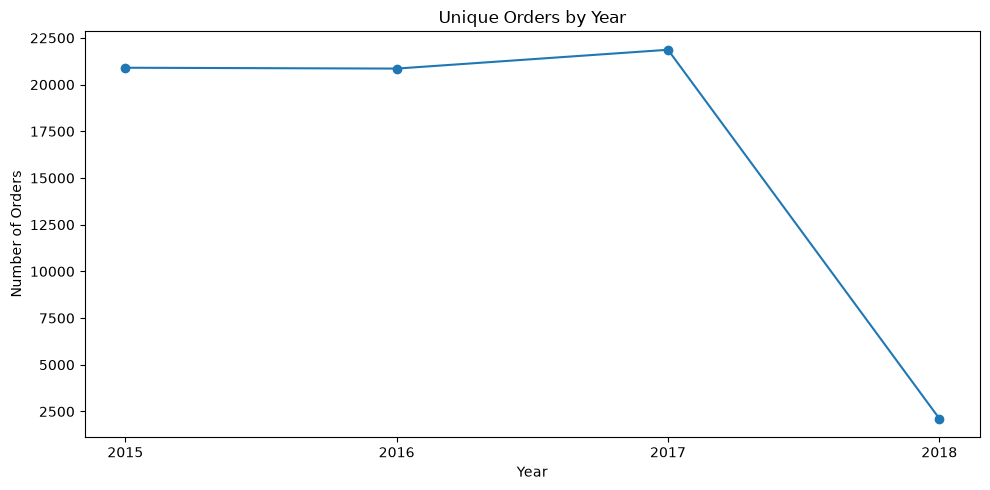

In [127]:
plt.figure(figsize=(10, 5))

plt.plot(
    orders_by_year["order_year"],
    orders_by_year["unique_orders"],
    marker="o"
)

plt.title("Unique Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

plt.xticks(orders_by_year["order_year"])

plt.tight_layout()
plt.show()

## 3.2 Order Volume by Month

In [128]:
orders_by_month = (
    df.groupby(
        ["order_year", "order_month"]
    )["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

orders_by_month["order_period"] = pd.to_datetime(
    orders_by_month["order_year"].astype(str)
    + "-"
    + orders_by_month["order_month"].astype(str)
    + "-01"
)

orders_by_month

,order_year,order_month,unique_orders,order_period
0,2015,1,1787,2015-01-01
1,2015,2,1585,2015-02-01
2,2015,3,1781,2015-03-01
3,2015,4,1710,2015-04-01
4,2015,5,1776,2015-05-01
5,2015,6,1725,2015-06-01
6,2015,7,1763,2015-07-01
7,2015,8,1762,2015-08-01
8,2015,9,1706,2015-09-01
9,2015,10,1775,2015-10-01


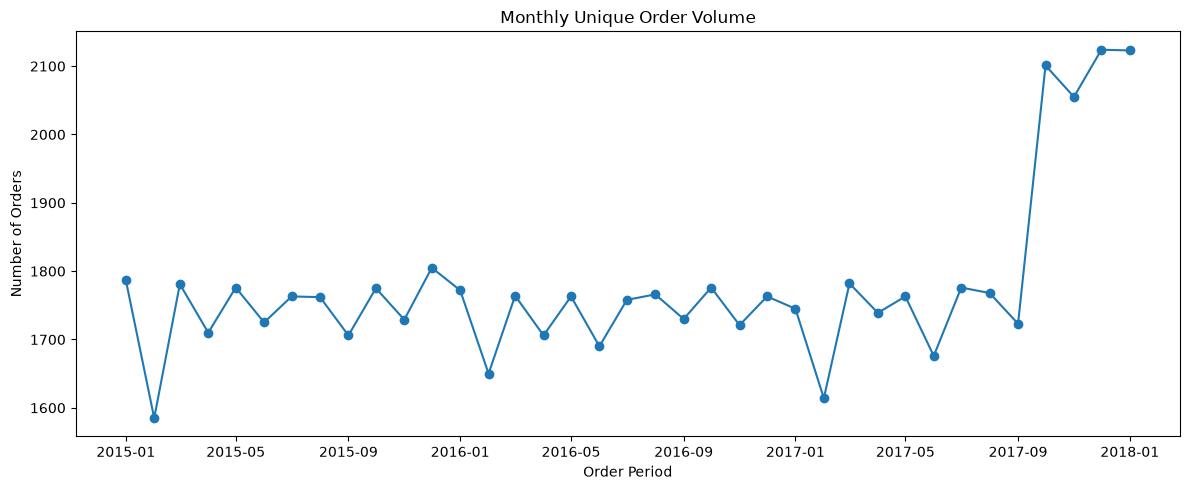

In [129]:
plt.figure(figsize=(12, 5))

plt.plot(
    orders_by_month["order_period"],
    orders_by_month["unique_orders"],
    marker="o"
)

plt.title("Monthly Unique Order Volume")
plt.xlabel("Order Period")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [130]:
print("=== ORDER VOLUME SUMMARY ===")

peak_month = orders_by_month.loc[
    orders_by_month["unique_orders"].idxmax()
]

lowest_month = orders_by_month.loc[
    orders_by_month["unique_orders"].idxmin()
]

print(
    f"Peak monthly order volume: "
    f"{peak_month['order_period'].strftime('%Y-%m')} "
    f"({peak_month['unique_orders']:,} orders)"
)

print(
    f"Lowest monthly order volume: "
    f"{lowest_month['order_period'].strftime('%Y-%m')} "
    f"({lowest_month['unique_orders']:,} orders)"
)

=== ORDER VOLUME SUMMARY ===
Peak monthly order volume: 2017-12 (2,124 orders)
Lowest monthly order volume: 2015-02 (1,585 orders)


### Key Findings

- Annual order volume remained relatively stable from 2015 to 2016.
- Order volume increased in 2017 compared with the previous two years.
- Monthly order volume was relatively stable through most of 2015–2017.
- Order volume increased noticeably from October 2017 onward.
- 2018 should not be compared directly with previous full years because the dataset only covers January 2018.

# 4. Delivery Performance Analysis

## 4.1 Shipping Performance Distribution

In [131]:
shipping_performance_summary = (
    df["shipping_performance"]
    .value_counts()
    .rename_axis("shipping_performance")
    .reset_index(name="order_items")
)

shipping_performance_summary["percentage"] = (
    shipping_performance_summary["order_items"]
    / len(df)
    * 100
).round(2)

shipping_performance_summary

,shipping_performance,order_items,percentage
0,Late,103400,57.28
1,Early,43366,24.02
2,On Time,33753,18.70


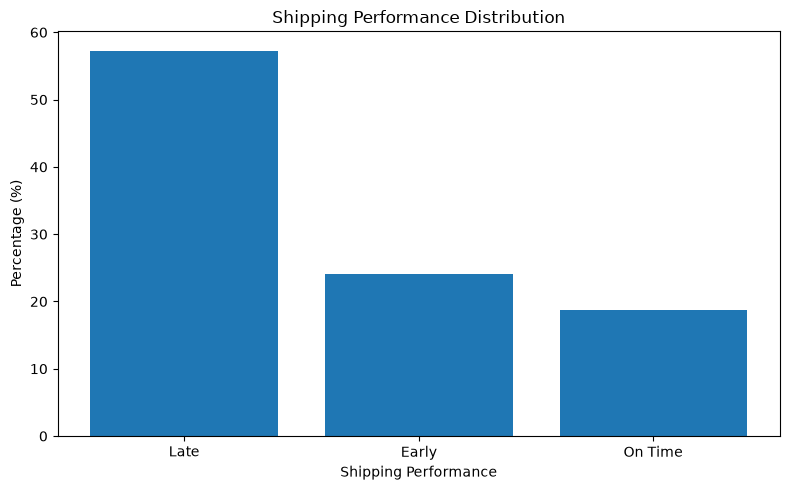

In [132]:
plt.figure(figsize=(8, 5))

plt.bar(
    shipping_performance_summary["shipping_performance"],
    shipping_performance_summary["percentage"]
)

plt.title("Shipping Performance Distribution")
plt.xlabel("Shipping Performance")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

### Key Findings

- **Late deliveries account for 57.28% of order items**, making delayed delivery the dominant shipping performance outcome.
- **Early deliveries account for 24.02%**, while only **18.70% of order items were delivered on time**.
- The distribution indicates that delivery reliability is a significant operational issue across the dataset.
- Further analysis is required to determine whether delays are concentrated by shipping mode, region, or product category.

# 5. Delivery Time Analysis

## 5.1 Overall Delivery Time

In [133]:
delivery_time_stats = pd.DataFrame({
    "metric": [
        "Average Delivery Time",
        "Median Delivery Time",
        "Minimum Delivery Time",
        "Maximum Delivery Time"
    ],
    "days": [
        df["days_for_shipping_real"].mean(),
        df["days_for_shipping_real"].median(),
        df["days_for_shipping_real"].min(),
        df["days_for_shipping_real"].max()
    ]
})

delivery_time_stats

,metric,days
0,Average Delivery Time,3.497654
1,Median Delivery Time,3.000000
2,Minimum Delivery Time,0.000000
3,Maximum Delivery Time,6.000000


## 5.2 Delivery Time Distribution

In [134]:
delivery_time_distribution = (
    df["days_for_shipping_real"]
    .value_counts()
    .sort_index()
    .reset_index()
)

delivery_time_distribution.columns = [
    "delivery_days",
    "order_items"
]

delivery_time_distribution["percentage"] = (
    delivery_time_distribution["order_items"]
    / len(df)
    * 100
).round(2)

delivery_time_distribution

,delivery_days,order_items,percentage
0,0,5080,2.81
1,1,4657,2.58
2,2,56618,31.36
3,3,28765,15.93
4,4,28513,15.80
5,5,28163,15.60
6,6,28723,15.91


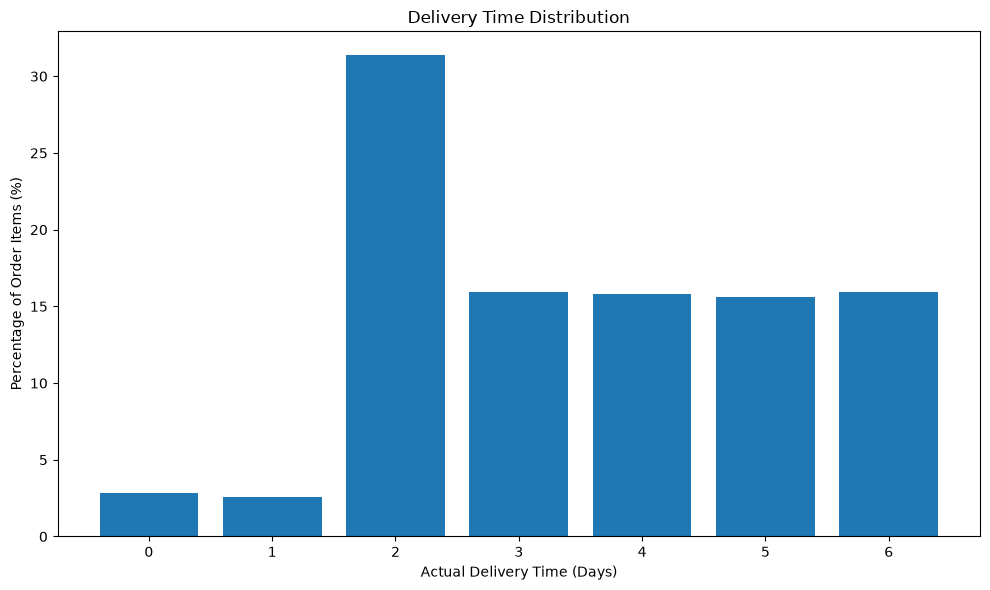

In [135]:
plt.figure(figsize=(10, 6))

plt.bar(
    delivery_time_distribution["delivery_days"],
    delivery_time_distribution["percentage"]
)

plt.title("Delivery Time Distribution")
plt.xlabel("Actual Delivery Time (Days)")
plt.ylabel("Percentage of Order Items (%)")

plt.xticks(
    delivery_time_distribution["delivery_days"]
)

plt.tight_layout()
plt.show()

### Key Findings

- Average actual delivery time was **3.50 days**, with a median of **3 days**.
- Delivery time ranged from **0 to 6 days**.
- **2-day delivery** was the most common, accounting for **31.36% of order items**.
- Delivery time distribution provides an overview of operational delivery duration, but does not by itself indicate whether the delivery met the scheduled expectation.
- Delivery performance therefore needs to be evaluated together with delay rate and shipping mode.

# 6. Delay Rate Analysis

## 6.1 Overall Delay Rate

In [136]:
total_order_items = len(df)

late_order_items = (
    df["is_late_delivery"] == 1
).sum()

non_late_order_items = (
    total_order_items - late_order_items
)

delay_rate = (
    late_order_items
    / total_order_items
    * 100
)

print(f"Total order items: {total_order_items:,}")
print(f"Late order items: {late_order_items:,}")
print(f"Non-late order items: {non_late_order_items:,}")
print(f"Delay rate: {delay_rate:.2f}%")

Total order items: 180,519
Late order items: 103,400
Non-late order items: 77,119
Delay rate: 57.28%


## 6.2 Delay Summary

In [137]:
delay_rate_summary = pd.DataFrame({
    "metric": [
        "Total Order Items",
        "Late Order Items",
        "Non-Late Order Items",
        "Delay Rate (%)"
    ],
    "value": [
        total_order_items,
        late_order_items,
        non_late_order_items,
        delay_rate
    ]
})

delay_rate_summary

,metric,value
0,Total Order Items,180519.000000
1,Late Order Items,103400.000000
2,Non-Late Order Items,77119.000000
3,Delay Rate (%),57.279289


## 6.3 Delay Severity

In [138]:
late_delivery_df = df[
    df["is_late_delivery"] == 1
].copy()

In [139]:
delay_severity = pd.DataFrame({
    "metric": [
        "Average Delay",
        "Median Delay",
        "Minimum Delay",
        "Maximum Delay"
    ],
    "days": [
        late_delivery_df["shipping_delay_days"].mean(),
        late_delivery_df["shipping_delay_days"].median(),
        late_delivery_df["shipping_delay_days"].min(),
        late_delivery_df["shipping_delay_days"].max()
    ]
})

delay_severity

,metric,days
0,Average Delay,1.616741
1,Median Delay,1.000000
2,Minimum Delay,1.000000
3,Maximum Delay,4.000000


### Key Findings

- Overall delay rate was **57.28%**, meaning more than half of the order items were delivered later than scheduled.
- Among late order items, the **average delay was 1.62 days**, with a median of **1 day**.
- Delay duration ranged from **1 to 4 days**.
- The combination of a high delay rate and measurable delay duration indicates that delivery reliability is a major operational issue.

# 7. Shipping Mode Analysis

## 7.1 Delivery Time by Shipping Mode

In [140]:
delivery_time_by_mode = (
    df.groupby(
        "shipping_mode",
        observed=True
    )
    .agg(
        order_items=("order_item_id", "count"),
        avg_delivery_days=(
            "days_for_shipping_real",
            "mean"
        ),
        median_delivery_days=(
            "days_for_shipping_real",
            "median"
        ),
        min_delivery_days=(
            "days_for_shipping_real",
            "min"
        ),
        max_delivery_days=(
            "days_for_shipping_real",
            "max"
        )
    )
    .sort_values("avg_delivery_days")
)

delivery_time_by_mode

,order_items,avg_delivery_days,median_delivery_days,min_delivery_days,max_delivery_days
shipping_mode,,,,,
Same Day,9737,0.478279,0.0,0,1
First Class,27814,2.000000,2.0,2,2
Second Class,35216,3.990828,4.0,2,6
Standard Class,107752,3.995907,4.0,2,6


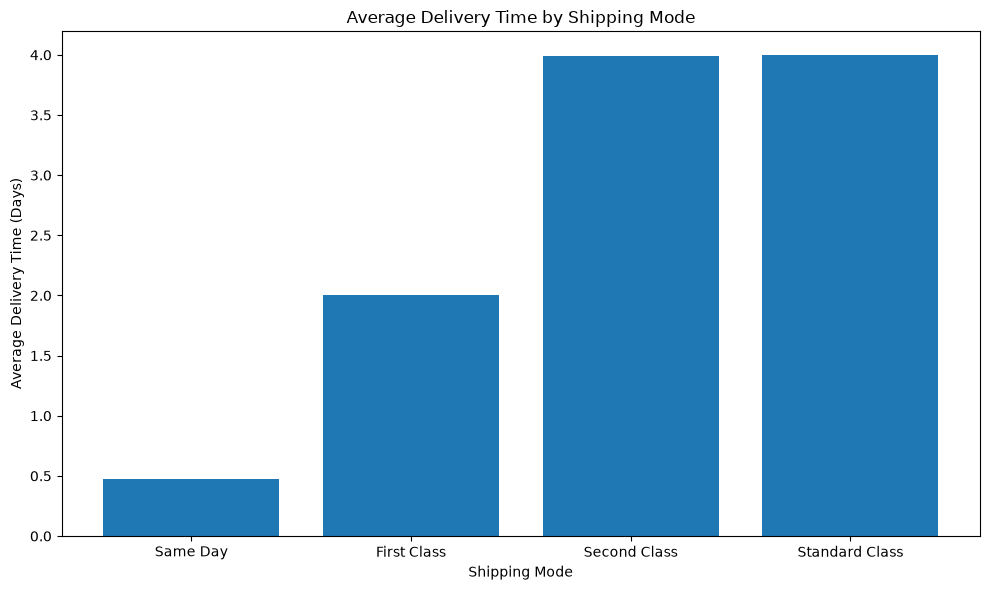

In [141]:
plt.figure(figsize=(10, 6))

plt.bar(
    delivery_time_by_mode.index,
    delivery_time_by_mode["avg_delivery_days"]
)

plt.title("Average Delivery Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delivery Time (Days)")

plt.tight_layout()
plt.show()

## 7.2 Delay Rate by Shipping Mode

In [142]:
delay_rate_by_mode = (
    df.groupby(
        "shipping_mode",
        observed=True
    )
    .agg(
        order_items=("order_item_id", "count"),
        late_order_items=("is_late_delivery", "sum")
    )
)

delay_rate_by_mode["delay_rate"] = (
    delay_rate_by_mode["late_order_items"]
    / delay_rate_by_mode["order_items"]
    * 100
)

delay_rate_by_mode = (
    delay_rate_by_mode
    .sort_values(
        "delay_rate",
        ascending=False
    )
)

delay_rate_by_mode

,order_items,late_order_items,delay_rate
shipping_mode,,,
First Class,27814,27814,100.000000
Second Class,35216,28078,79.730804
Same Day,9737,4657,47.827873
Standard Class,107752,42851,39.768171


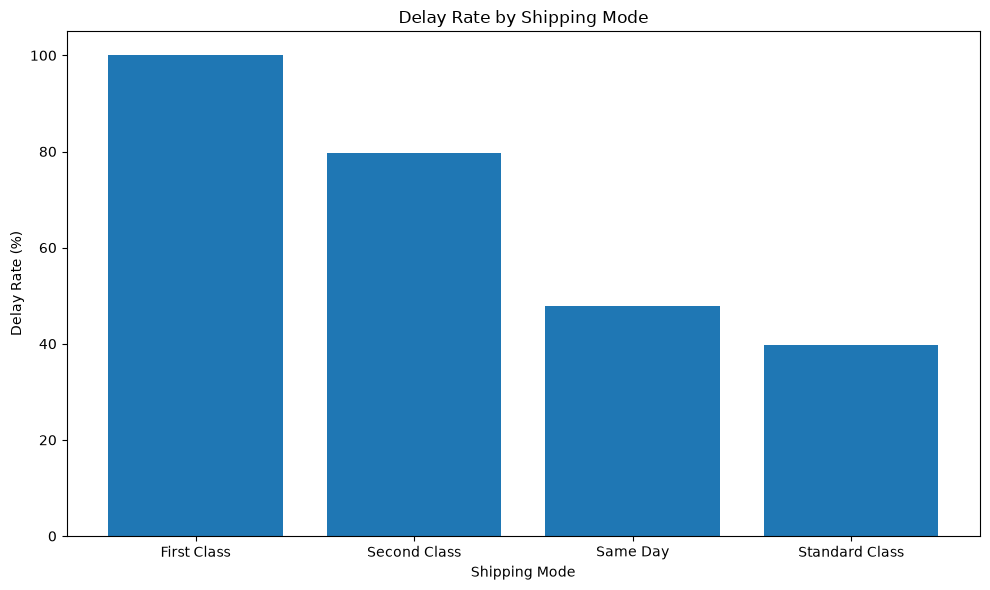

In [143]:
plt.figure(figsize=(10, 6))

plt.bar(
    delay_rate_by_mode.index,
    delay_rate_by_mode["delay_rate"]
)

plt.title("Delay Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Delay Rate (%)")

plt.tight_layout()
plt.show()

## 7.3 Delay Severity by Shipping Mode

In [144]:
late_delay_by_mode = (
    df[df["is_late_delivery"] == 1]
    .groupby(
        "shipping_mode",
        observed=True
    )
    .agg(
        late_order_items=("order_item_id", "count"),
        avg_delay_days=(
            "shipping_delay_days",
            "mean"
        ),
        median_delay_days=(
            "shipping_delay_days",
            "median"
        ),
        max_delay_days=(
            "shipping_delay_days",
            "max"
        )
    )
    .sort_values(
        "avg_delay_days",
        ascending=False
    )
)

late_delay_by_mode

,late_order_items,avg_delay_days,median_delay_days,max_delay_days
shipping_mode,,,,
Second Class,28078,2.496937,2.0,4
Standard Class,42851,1.507339,2.0,2
Same Day,4657,1.000000,1.0,1
First Class,27814,1.000000,1.0,1


### Key Findings

- **First Class has the highest delay rate at 100%**, indicating that every First Class order item in this dataset was delivered later than scheduled.
- **Second Class has a delay rate of approximately 79.73%**, making it the second-worst shipping mode by delivery reliability.
- **Standard Class has the lowest delay rate at approximately 39.77%**, although it represents the largest order-item volume.
- Same Day has the shortest average delivery time at approximately **0.48 days**, but its delay rate is still **47.83%**.
- Shipping mode affects both delivery duration and delivery reliability; therefore, shipping mode should be considered when evaluating operational performance.

# 8. Region Performance Analysis

## 8.1 Region Overview

In [145]:
region_list = (
    df["order_region"]
    .value_counts()
    .rename_axis("order_region")
    .reset_index(name="order_items")
)

region_list

,order_region,order_items
0,Central America,28341
1,Western Europe,27109
2,South America,14935
3,Oceania,10148
4,Northern Europe,9792
5,Southeast Asia,9539
6,Southern Europe,9431
7,Caribbean,8318
8,West of USA,7993
9,South Asia,7731


## 8.2 Regional Performance

In [146]:
region_performance = (
    df.groupby(
        "order_region",
        observed=True
    )
    .agg(
        order_items=("order_item_id", "count"),
        late_order_items=("is_late_delivery", "sum"),
        avg_delivery_days=(
            "days_for_shipping_real",
            "mean"
        )
    )
)

region_performance["delay_rate"] = (
    region_performance["late_order_items"]
    / region_performance["order_items"]
    * 100
)

region_performance = (
    region_performance
    .sort_values(
        "delay_rate",
        ascending=False
    )
)

region_performance

,order_items,late_order_items,avg_delivery_days,delay_rate
order_region,,,,
Central Africa,1677,1018,3.560525,60.703637
Western Europe,27109,15863,3.498432,58.515622
South Asia,7731,4523,3.502005,58.504721
South of USA,4045,2350,3.492707,58.096415
Southeast Asia,9539,5531,3.496698,57.983017
East of USA,6915,4009,3.500940,57.975416
West Asia,6009,3455,3.486770,57.497088
East Africa,1852,1064,3.514579,57.451404
Eastern Europe,3920,2252,3.500765,57.448980


## 8.3 Delay Severity by Region

In [147]:
late_region_performance = (
    df[df["is_late_delivery"] == 1]
    .groupby(
        "order_region",
        observed=True
    )
    .agg(
        late_order_items=("order_item_id", "count"),
        avg_delay_days=(
            "shipping_delay_days",
            "mean"
        ),
        median_delay_days=(
            "shipping_delay_days",
            "median"
        ),
        max_delay_days=(
            "shipping_delay_days",
            "max"
        )
    )
    .sort_values(
        "avg_delay_days",
        ascending=False
    )
)

late_region_performance

,late_order_items,avg_delay_days,median_delay_days,max_delay_days
order_region,,,,
Central Asia,316,1.677215,1.0,4
Eastern Asia,4130,1.654964,1.0,4
West of USA,4524,1.641689,1.0,4
South of USA,2350,1.639149,1.0,4
Northern Europe,5524,1.633056,1.0,4
South Asia,4523,1.629671,1.0,4
West Africa,2033,1.629120,1.0,4
Western Europe,15863,1.628885,1.0,4
Eastern Europe,2252,1.624778,1.0,4


## 8.4 Final Regional Summary

In [148]:
region_summary = (
    region_performance
    .join(
        late_region_performance[
            [
                "avg_delay_days",
                "median_delay_days",
                "max_delay_days"
            ]
        ]
    )
    .sort_values(
        "delay_rate",
        ascending=False
    )
)

region_summary

,order_items,late_order_items,avg_delivery_days,delay_rate,avg_delay_days,median_delay_days,max_delay_days
order_region,,,,,,,
Central Africa,1677,1018,3.560525,60.703637,1.601179,1.0,4
Western Europe,27109,15863,3.498432,58.515622,1.628885,1.0,4
South Asia,7731,4523,3.502005,58.504721,1.629671,1.0,4
South of USA,4045,2350,3.492707,58.096415,1.639149,1.0,4
Southeast Asia,9539,5531,3.496698,57.983017,1.602784,1.0,4
East of USA,6915,4009,3.500940,57.975416,1.599401,1.0,4
West Asia,6009,3455,3.486770,57.497088,1.600000,1.0,4
East Africa,1852,1064,3.514579,57.451404,1.590226,1.0,4
Eastern Europe,3920,2252,3.500765,57.448980,1.624778,1.0,4


## 8.5 Delay Rate

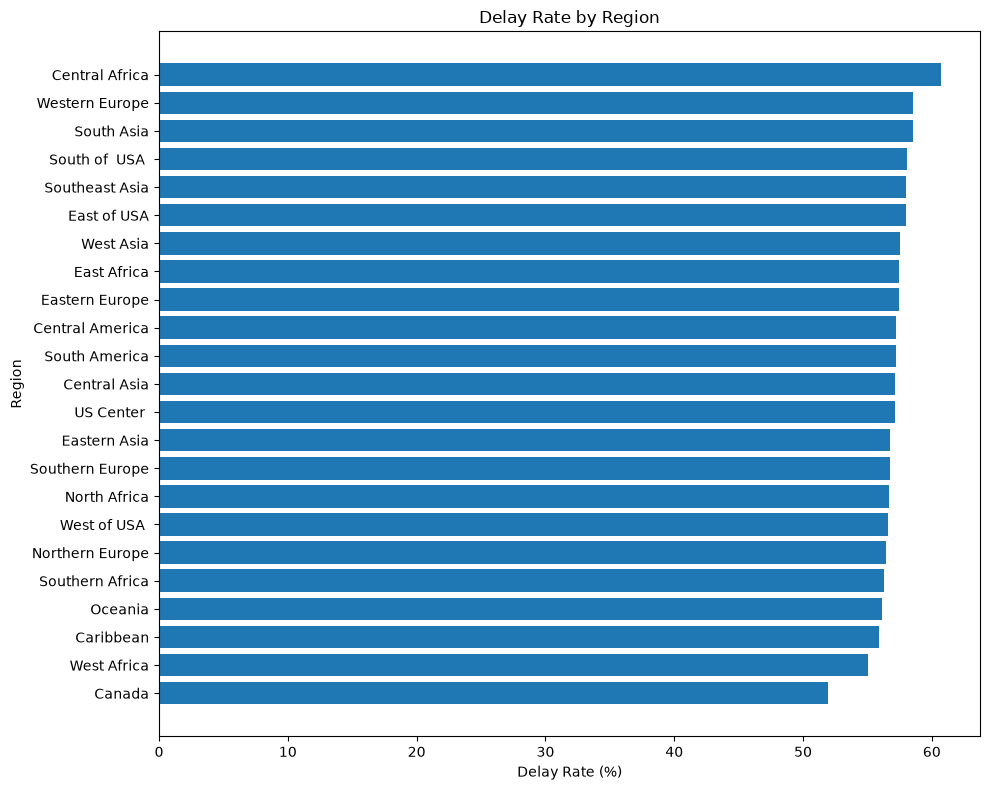

In [149]:
region_delay_rate = (
    df.groupby(
        "order_region",
        observed=True
    )
    .agg(
        order_items=("order_item_id", "count"),
        late_order_items=("is_late_delivery", "sum")
    )
    .assign(
        delay_rate=lambda x:
            x["late_order_items"]
            / x["order_items"]
            * 100
    )
    .sort_values(
        "delay_rate",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    region_delay_rate.index,
    region_delay_rate["delay_rate"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Region")
plt.title("Delay Rate by Region")

plt.tight_layout()
plt.show()

## 8.6 Average Delay by Region

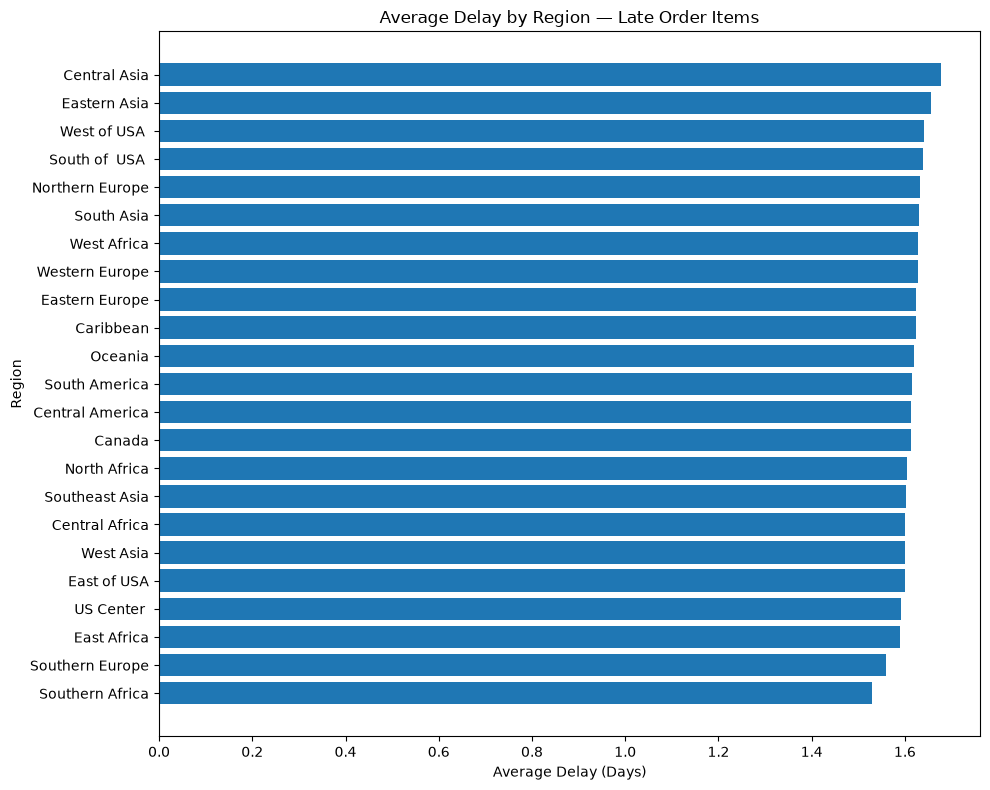

In [150]:
region_avg_delay = (
    df[df["is_late_delivery"] == 1]
    .groupby(
        "order_region",
        observed=True
    )
    .agg(
        late_order_items=("order_item_id", "count"),
        avg_delay_days=(
            "shipping_delay_days",
            "mean"
        )
    )
    .sort_values(
        "avg_delay_days",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    region_avg_delay.index,
    region_avg_delay["avg_delay_days"]
)

plt.xlabel("Average Delay (Days)")
plt.ylabel("Region")
plt.title(
    "Average Delay by Region — Late Order Items"
)

plt.tight_layout()
plt.show()

### Key Findings

- **Central Africa has the highest delay rate at 60.70%**, indicating the weakest delivery reliability among the analyzed regions.

- **Central Asia has the highest average delay at 1.68 days among late order items**, despite having a lower delay rate than Central Africa.

- **Canada has the lowest delay rate at 51.93%**, but more than half of its order items are still delayed.

- The delay rate ranges from **51.93% to 60.70%**, indicating that delivery delays are widespread across regions rather than being isolated to a single region.

- Delay frequency and delay severity provide different perspectives, so both metrics should be considered when evaluating regional delivery performance.

# 9. Product / Category Delivery Analysis

## 9.1 Category Performance

In [151]:
category_delivery = (
    df.groupby(
        "category_name",
        observed=True
    )
    .agg(
        order_items=("order_item_id", "count"),
        late_order_items=("is_late_delivery", "sum"),
        avg_delivery_days=(
            "days_for_shipping_real",
            "mean"
        )
    )
    .assign(
        delay_rate=lambda x:
            x["late_order_items"]
            / x["order_items"]
            * 100
    )
    .sort_values(
        "delay_rate",
        ascending=False
    )
)

category_delivery

,order_items,late_order_items,avg_delivery_days,delay_rate
category_name,,,,
Golf Bags & Carts,61,42,3.344262,68.852459
Lacrosse,343,213,3.618076,62.099125
Cameras,592,367,3.337838,61.993243
Pet Supplies,492,302,3.388211,61.382114
Sporting Goods,357,214,3.490196,59.943978
Basketball,67,40,3.462687,59.701493
Fitness Accessories,309,184,3.572816,59.546926
Crafts,484,288,3.578512,59.504132
Strength Training,111,66,3.747748,59.459459


## 9.2 Delay Rate by Category

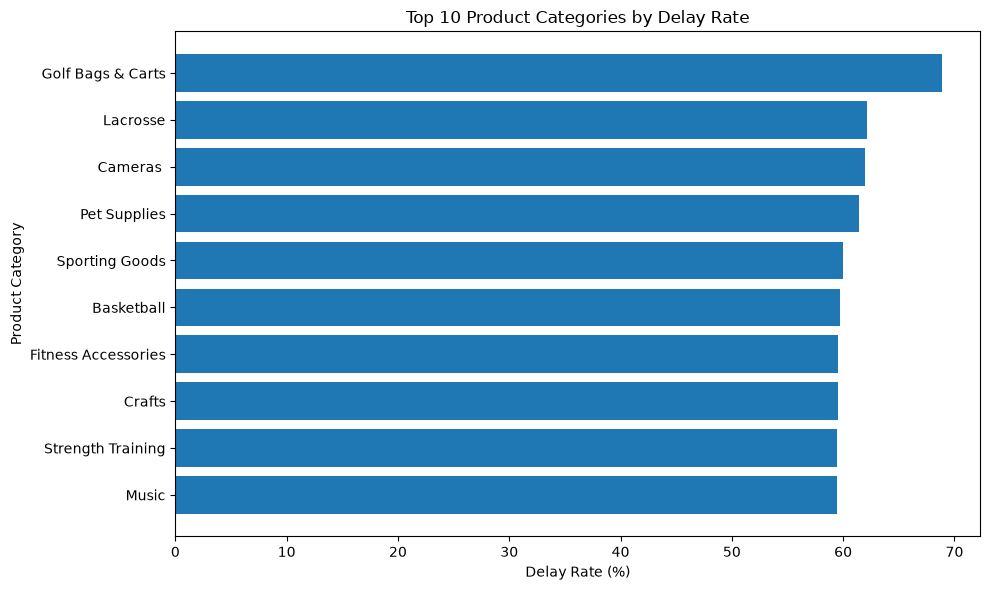

In [152]:
top_delay_categories = (
    category_delivery
    .sort_values(
        "delay_rate",
        ascending=False
    )
    .head(10)
    .sort_values("delay_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_delay_categories.index,
    top_delay_categories["delay_rate"]
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Product Category")
plt.title(
    "Top 10 Product Categories by Delay Rate"
)

plt.tight_layout()
plt.show()

## 9.3 Average Delay by Category

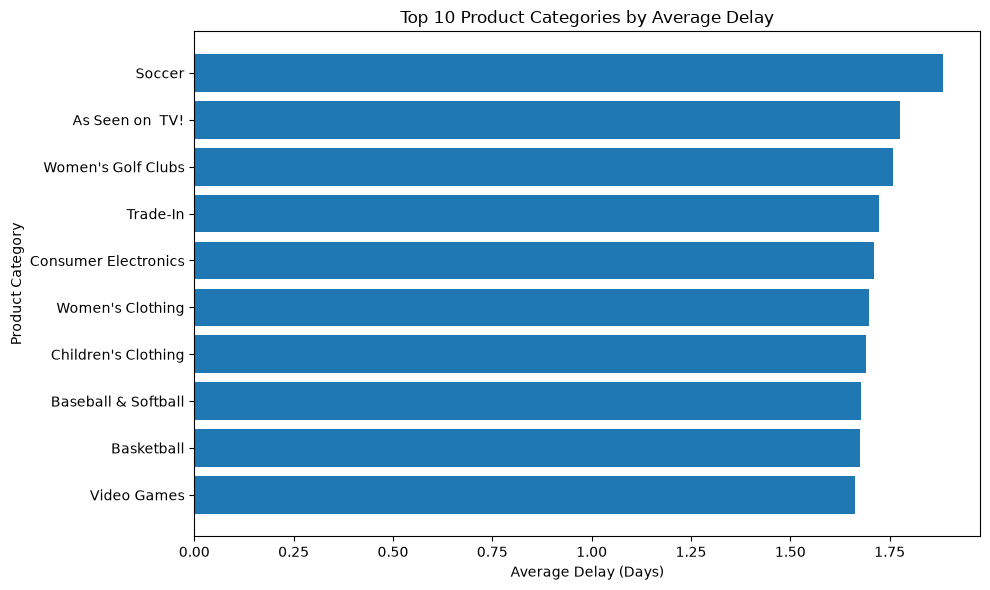

In [153]:
category_avg_delay = (
    df[df["is_late_delivery"] == 1]
    .groupby(
        "category_name",
        observed=True
    )
    .agg(
        late_order_items=("order_item_id", "count"),
        avg_delay_days=(
            "shipping_delay_days",
            "mean"
        )
    )
    .sort_values(
        "avg_delay_days",
        ascending=False
    )
    .head(10)
    .sort_values("avg_delay_days")
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_avg_delay.index,
    category_avg_delay["avg_delay_days"]
)

plt.xlabel("Average Delay (Days)")
plt.ylabel("Product Category")
plt.title(
    "Top 10 Product Categories by Average Delay"
)

plt.tight_layout()
plt.show()

### Key Findings

- **Golf Bags & Carts has the highest delay rate at 68.85%**, indicating a high frequency of delivery delays. However, this category has only 61 order items, so the result should be interpreted with caution.

- **Lacrosse, Cameras, and Pet Supplies also show delay rates above 60%**, suggesting that delivery issues are not limited to a single product category.

- **Soccer has the highest average delay duration at approximately 1.88 days among late order items**, followed by As Seen on TV! and Women's Golf Clubs.

- The categories with the highest delay rate are not necessarily the categories with the longest average delay. This indicates that **delay frequency and delay severity represent different aspects of delivery performance**.

- Delivery delays occur across a wide range of product categories, suggesting that broader logistics or fulfillment factors may contribute to the issue.

# 10. Overall Summary

The exploratory analysis provides a comprehensive view of order volume and delivery performance across time, shipping modes, regions, and product categories.

The analysis shows that order volume remained relatively stable across most of the period, with an increase in 2017 and a noticeable rise from October 2017 onward. Delivery performance, however, represents a significant operational challenge, with **57.28% of order items delivered late**.

Actual delivery time averaged approximately **3.50 days**, while late deliveries experienced an average delay of approximately **1.62 days**.

Shipping mode analysis shows substantial differences in delivery reliability. First Class recorded the highest delay rate, while Standard Class had the lowest delay rate among the four shipping modes.

Regional analysis indicates that delays are widespread across regions, with Central Africa recording the highest delay rate and Central Asia recording the highest average delay duration among late deliveries.

Product category analysis also shows variation in delivery performance. Some categories have particularly high delay rates, although categories with small order volumes should be interpreted cautiously.

Overall, the EDA indicates that delivery delays are not isolated to a single region, shipping mode, or product category. The findings suggest that delivery reliability should be monitored across multiple operational dimensions rather than through a single KPI.